# Case Study for Practical Machine Learning: Detecting Cracks in Images.

## Scenarios description:

> In this scenario, machine learning can be applied to detect abnormal cracks in images captured from a factory's equipment or infrastructure. The goal is to automatically identify potential defects or damages that could lead to failures, ensuring the equipment's safety and operational efficiency.

> By using machine learning and deep models, the system learns to differentiate between normal wear and tear and more significant cracks that need attention. This can help in predictive maintenance, reducing downtime and preventing costly repairs.

![](https://drive.google.com/uc?export=view&id=15DykdcKWnw5ZmhPJSgKh8YqL-Kuy1e-I)


## In this case study you will

1. Recall machine learning algorithms, deep learning knowledge that can be applied to solve this problem

2. Apply these algorithms to build several models that are capable of predicting whether an image contains cracks.

3. Practice the basic pipeline for deep learning task:

> a. Define the dataset (load the data, dataset splitting) \
  b. Define the model, including model structure and forward function. \
  c. Define the optimizer and loss function. \
  d. Set other parameters (training epochs) and start training.

In [1]:
"""
Step 1: import crucial packages
"""
import os
import csv
import random
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torch.optim as optim

In [2]:
"""
Step 2: get the dataset.
- Google Colab: upload Concrete_Crack_Images.zip when prompted.
- Running locally: put Concrete_Crack_Images.zip in the repo's data/ folder (see data/README.md).
"""
import os, zipfile

ZIP_NAME = 'Concrete_Crack_Images.zip'
try:
    from google.colab import files  # only available on Colab
    if not os.path.exists(ZIP_NAME):
        files.upload()
    zip_path = ZIP_NAME
except ImportError:
    zip_path = os.path.join('..', 'data', ZIP_NAME)

if not os.path.isdir('Concrete_Crack_Images'):
    with zipfile.ZipFile(zip_path) as z:
        z.extractall('Concrete_Crack_Images')
print(os.listdir('Concrete_Crack_Images/Concrete_Crack_Images'))

['Negative_img', 'Positive_img']


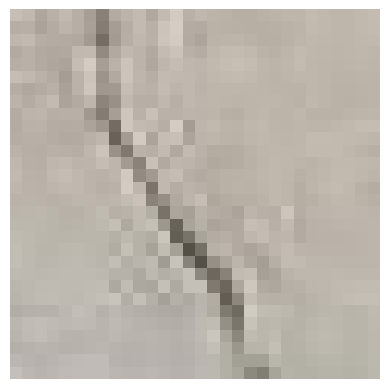

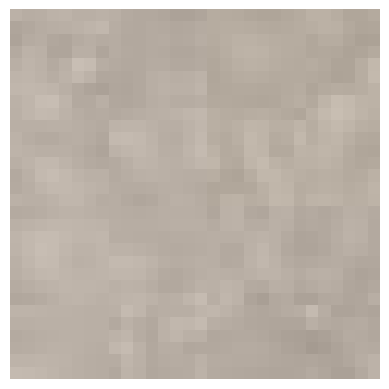

In [3]:
"""
Step 3: try to visualize data
"""
# Visualization of positive data (cracks)
positive_id = "02433" # modify following
negative_id = "00666"

def visualize_one_sample(path, index):
    sample_image = Image.open(os.path.join(path, f"{index}.jpg"))

    plt.imshow(sample_image, cmap = "gray")
    plt.axis('off')
    plt.show()

visualize_one_sample("Concrete_Crack_Images/Concrete_Crack_Images/Positive_img/", positive_id)
visualize_one_sample("Concrete_Crack_Images/Concrete_Crack_Images/Negative_img/", negative_id)

In [4]:
"""
Step 4: Define the dataset and create a dataset object
"""
class Concrete_Img(Dataset):
    def __init__(self, root_dir):
      self.root_dir = root_dir
      self.neg_path = os.path.join(root_dir, 'Negative_img')
      self.pos_path = os.path.join(root_dir, 'Positive_img')

      self.neg_images = [os.path.join(self.neg_path, img) for img in os.listdir(self.neg_path)]
      self.pos_images = [os.path.join(self.pos_path, img) for img in os.listdir(self.pos_path)]
      self.all_images = self.neg_images + self.pos_images
      # Labels: 0 for 'neg', 1 for 'pos'
      self.labels = [0] * len(self.neg_images) + [1] * len(self.pos_images)

    def __len__(self):
        # Total number of images in the dataset
        return len(self.all_images)

    def __getitem__(self, idx):
        img_path = self.all_images[idx] # get the directory given index
        image = Image.open(img_path).convert('L') # load the data from directory
        image = np.array(image)
        # Convert to a float tensor, scale pixels to [0, 1], add channel dim -> (1, 30, 30)
        image = torch.tensor(image, dtype=torch.float32).unsqueeze(0) / 255.0
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image, label

# Create the crack dataset
root_dir = './Concrete_Crack_Images/Concrete_Crack_Images/'
concrete_dataset = Concrete_Img(root_dir)
print(f"Dataset size: {len(concrete_dataset)}")
img, lbl = concrete_dataset[0]
print(f"Image shape: {img.shape}, Label: {lbl}")

Dataset size: 10000
Image shape: torch.Size([1, 30, 30]), Label: 0


In [5]:
"""
Step 5: Split dataset into training, testing and validation subsets.
"""
# Define the size of each split
train_size = int(0.8 * len(concrete_dataset))  # 80% of the dataset
val_size = int(0.1 * len(concrete_dataset))   # 10% of the dataset
test_size = len(concrete_dataset) - train_size - val_size  # Remaining 10% of the dataset
torch.manual_seed(0)
# Split the dataset
train_dataset, val_dataset, test_dataset = random_split(concrete_dataset, [train_size, val_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size = 32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [7]:
"""
Step 5: Define the deep model based on the convolution neural network
"""
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Conv block 1: 1 input channel (greyscale) -> 4 feature maps
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=4, kernel_size=3, padding=1)
        # Conv block 2: 4 -> 8 feature maps
        self.conv2 = nn.Conv2d(in_channels=4, out_channels=8, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # halves width and height
        # After two pools: 30x30 -> 15x15 -> 7x7, with 8 channels
        self.fc = nn.Linear(8 * 7 * 7, 2)  # 2 classes: no crack / crack

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  # (B, 4, 15, 15)
        x = self.pool(self.relu(self.conv2(x)))  # (B, 8, 7, 7)
        x = torch.flatten(x, 1)                  # (B, 392)
        x = self.fc(x)                           # (B, 2) raw scores (logits)

        return x

model = SimpleCNN()
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("model size:{}".format(total_params))

model size:1122


In [9]:
"""
Step 6: Define the optimizer and loss function
"""
# loss function, optimizers
criterion = nn.CrossEntropyLoss()                     # standard loss for classification (takes raw logits)
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam with a typical learning rate

# other parameters
num_epochs = 10
best_acc = 0

In [10]:
"""
Step 7: write the training loop
"""
# Training loop
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        # Forward pass to get outputs
        outputs = model(inputs)

        # Calculate the loss
        # print(f"{outputs.shape}\t{labels.shape}")
        loss = criterion(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()  # clear old gradients
        loss.backward()        # compute new gradients
        optimizer.step()       # update the weights

        # Get statistics
        running_loss += loss.item()

    # Print average loss for the epoch
    print(f'Epoch {epoch+1}/{num_epochs} - Training loss: {running_loss/len(train_loader)}')

    # Validation loop
    model.eval()  # Set the model to evaluation mode
    val_running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():  # No gradients need to be computed for validation
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()

            # Calculate accuracy
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Print average validation loss and accuracy for the epoch
    print(f'Epoch {epoch+1}/{num_epochs} - Validation loss: {val_running_loss/len(val_loader)}')
    print(f'Epoch {epoch+1}/{num_epochs} - Validation accuracy: {100 * correct / total}%')

    # Save the model if the current accuracy is the best so far
    acc = 100 * correct / total
    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), 'best_model_cnn.pth')
        print(f'Model improved and saved with accuracy: {acc}%')

print('Finished Training')

Epoch 1/10 - Training loss: 0.3494132685959339
Epoch 1/10 - Validation loss: 0.1272481078049168
Epoch 1/10 - Validation accuracy: 96.7%
Model improved and saved with accuracy: 96.7%
Epoch 2/10 - Training loss: 0.1078227069452405
Epoch 2/10 - Validation loss: 0.08024006366031244
Epoch 2/10 - Validation accuracy: 97.3%
Model improved and saved with accuracy: 97.3%
Epoch 3/10 - Training loss: 0.07693387823924422
Epoch 3/10 - Validation loss: 0.06708840536884964
Epoch 3/10 - Validation accuracy: 97.4%
Model improved and saved with accuracy: 97.4%
Epoch 4/10 - Training loss: 0.06607847741618753
Epoch 4/10 - Validation loss: 0.05754928514943458
Epoch 4/10 - Validation accuracy: 98.3%
Model improved and saved with accuracy: 98.3%
Epoch 5/10 - Training loss: 0.05695051769167185
Epoch 5/10 - Validation loss: 0.05164619514835067
Epoch 5/10 - Validation accuracy: 98.5%
Model improved and saved with accuracy: 98.5%
Epoch 6/10 - Training loss: 0.054951037876307965
Epoch 6/10 - Validation loss: 0.05

## Further instructions

Free free to adjust some hyperparameters (learning rate, etc.) to see how they influence the model's performance. (**Re-run step 6 and 7**)

In [11]:
"""
Step 8: Inference on test datasets, make sure we load the best model
"""
model_best = SimpleCNN()
model_best.load_state_dict(torch.load('best_model_cnn.pth'))

# Validation loop
model_best.eval()  # Set the model to evaluation mode
correct = 0
total = 0
with torch.no_grad():  # No gradients need to be computed for validation
    for inputs, labels in tqdm(test_loader):
        outputs = model_best(inputs)
        # Calculate accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
acc = 100 * correct / total
print(f"Best model's accuracy on the test dataset: {acc}%")

100%|██████████| 32/32 [00:00<00:00, 91.06it/s]

Best model's accuracy on the test dataset: 99.0%
